## Linear Regression Implementation

In [ ]:
# importing the libraries
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# data
np.random.seed(42)
X = 2 * np.random.rand(100)
y = 1 + 2 * X + np.random.randn(100) * 0.3

Iteration 0: w=0.677, b=0.576, loss=9.6761
Iteration 50: w=1.876, b=1.126, loss=0.0738
Iteration 100: w=1.921, b=1.076, loss=0.0726
Iteration 150: w=1.929, b=1.066, loss=0.0726
Iteration 200: w=1.931, b=1.065, loss=0.0726
Iteration 250: w=1.931, b=1.065, loss=0.0726
Iteration 300: w=1.931, b=1.065, loss=0.0726
Iteration 350: w=1.931, b=1.065, loss=0.0726
Iteration 400: w=1.931, b=1.065, loss=0.0726
Iteration 450: w=1.931, b=1.065, loss=0.0726
Learned w: 1.9310  (true: 2.0)
Learned b: 1.0645  (true: 1.0)


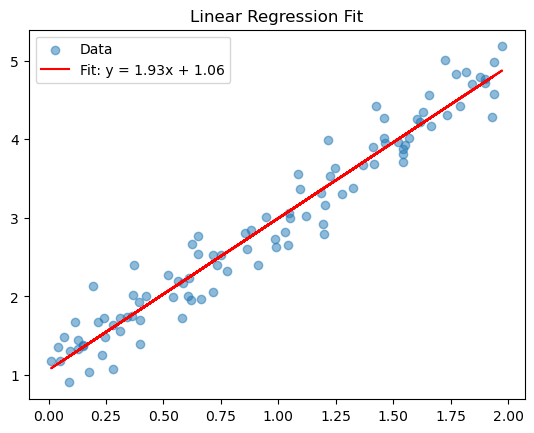

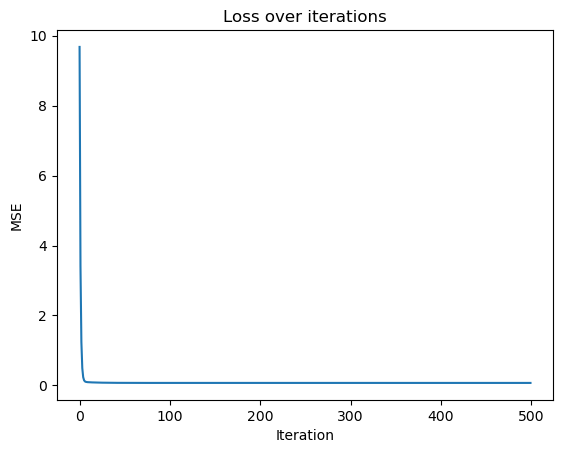

In [ ]:
# model
class LinearRegressionFromScratch:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iter = n_iterations
        self.w = 0.0
        self.b = 0.0
        self.loss_history = []

    def predict(self, X):
        return self.w * X + self.b

    def mse(self, y_true, y_pred):
        return np.mean((y_true - y_pred) ** 2)

    def fit(self, X, y):
        n = len(X)
        for _ in range(self.n_iter):
            y_pred = self.predict(X)
            error = y - y_pred

            # gradients
            dw = (-2/n) * np.sum(error * X)
            db = (-2/n) * np.sum(error)

            # update
            self.w -= self.lr * dw
            self.b -= self.lr * db

            self.loss_history.append(self.mse(y, y_pred))

            if _ % 50 == 0:
                print(f"Iteration {_}: w={self.w:.3f}, b={self.b:.3f}, loss={self.loss_history[-1]:.4f}")

    def plot_fit(self, X, y):
        plt.scatter(X, y, alpha=0.5, label='Data')
        plt.plot(X, self.predict(X), color='red', label=f'Fit: y = {self.w:.2f}x + {self.b:.2f}')
        plt.legend()
        plt.title("Linear Regression Fit")
        plt.show()

    def plot_loss(self):
        plt.plot(self.loss_history)
        plt.title("Loss over iterations")
        plt.xlabel("Iteration")
        plt.ylabel("MSE")
        plt.show()

# training
model = LinearRegressionFromScratch(learning_rate=0.1, n_iterations=500)
model.fit(X, y)

print(f"Learned w: {model.w:.4f}  (true: 2.0)")
print(f"Learned b: {model.b:.4f}  (true: 1.0)")

model.plot_fit(X, y)
model.plot_loss()

In [4]:
# scikit-learn comparison
from sklearn.linear_model import LinearRegression
sk_model = LinearRegression()
sk_model.fit(X.reshape(-1, 1), y)
print(f"Sklearn w: {sk_model.coef_[0]:.4f}")
print(f"Sklearn b: {sk_model.intercept_:.4f}")

Sklearn w: 1.9310
Sklearn b: 1.0645
